In [2]:
import pandas as pd
import glob
import os
import re

USAGE_DIR = 'source/dataset/useage'
# Target counts from your PRISMA Diagram (Identification Box)
TARGET_COUNTS = {
    'Google Scholar': 1690,
    'PubMed': 216,
    'Scopus': 388,
    'ArXiv': 1434
}

bib_content = """
@article{Liu2024, title = {A Contrastive Pretrain Model with Prompt Tuning for Multi-center Medication Recommendation}}
@article{Mi2024, title = {ACDNet: Attention-guided Collaborative Decision Network for effective medication recommendation}}
@article{MR1, title = {Conditional Generation Net for Medication Recommendation; Conditional Generation Net for Medication Recommendation}}
@article{RACI2024, title = {Contrastive Learning on Medical Intents for Sequential Prescription Recommendation}}
@article{Zheng2024, title = {CycleTrans: a transformer-based clinical foundation model for safer prescription}}
@article{TR1, title = {Large Language Model Distilling Medication Recommendation Model}}
@article{Pais2024, title = {Large language models for preventing medication direction errors in online pharmacies}}
@article{Zhao2024, title = {Leave No Patient Behind: Enhancing Medication Recommendation for Rare Disease Patients}}
@article{Belkadi2025, title = {LT3: Generating Medication Prescriptions with Conditional Transformer}}
@article{Jiang2021, title = {Medication Error Detection Using Contextual Language Models}}
@article{Como2024, title = {REFINE: A Fine-Grained Medication Recommendation System Using Deep Learning and Personalized Drug Interaction Modeling}}
@article{PhanVan2024, title = {Rx Strategist: Prescription Verification using LLM Agents System}}
@article{Wang2022, title = {Safe medicine recommendation via star interactive enhanced-based transformer model}}
@article{Li2024, title = {Transformer-based medication recommendation with a multiple graph augmentation strategy}}
@article{Zhang2017, title = {LEAP: Learning to prescribe effective and safe treatment combinations for multimorbidity}}
@article{MRS1, title = {Knowledge graph driven medicine recommendation system using graph neural networks on longitudinal medical records}}
"""


def normalize_text(text):
    if not isinstance(text, str): return ""
    return " ".join(re.sub(r'[^a-z0-9]', ' ', text.lower()).split())


# Parse titles from the BIB content above
protected_titles = []
for line in bib_content.split('\n'):
    if 'title' in line:
        # Extract content inside { }
        match = re.search(r'title\s*=\s*{(.*?)}', line)
        if match:
            protected_titles.append(normalize_text(match.group(1)))

print(f"Protected {len(protected_titles)} papers (from your final selection).")


# --- Step 2: Helper Function to Downsample ---
def downsample_csv(file_path, target_count, protected_set):
    try:
        df = pd.read_csv(file_path)
        original_count = len(df)

        # Identify Title Column
        title_col = next((c for c in df.columns if c.strip().lower() == 'title'), None)
        if not title_col:
            print(f"Skipping {file_path}: No title column.")
            return

        # Normalize titles for matching
        df['clean_title_temp'] = df[title_col].apply(normalize_text)

        # Separate into Protected and Disposable
        # We check if the paper title contains any of the protected titles
        # (Using a loose match to be safe)
        pattern = '|'.join([re.escape(t[:50]) for t in protected_set])  # Match first 50 chars

        mask_protected = df['clean_title_temp'].str.contains(pattern, case=False, regex=True)
        df_protected = df[mask_protected]
        df_disposable = df[~mask_protected]

        protected_count = len(df_protected)
        needed = target_count - protected_count

        if needed < 0:
            print(
                f"Warning for {file_path}: Protected papers ({protected_count}) exceed target ({target_count}). Keeping all protected.")
            final_df = df_protected
        elif needed > len(df_disposable):
            print(f"Warning for {file_path}: Not enough data to reach target {target_count}. Keeping all.")
            final_df = df
        else:
            # Randomly sample the remaining needed amount
            df_sampled = df_disposable.sample(n=needed, random_state=42)  # Random state for reproducibility
            final_df = pd.concat([df_protected, df_sampled])

        # Clean up temp column
        final_df = final_df.drop(columns=['clean_title_temp'])

        # Save
        final_df.to_csv(file_path, index=False)
        print(f"Updated {os.path.basename(file_path)}: {original_count} -> {len(final_df)} (Target: {target_count})")

    except Exception as e:
        print(f"Error processing {file_path}: {e}")


# --- Step 3: Execute ---
def classify_source(filename):
    clean_name = re.sub(r'[^a-z]', '', filename.lower())
    if 'pubmed' in clean_name:
        return 'PubMed'
    elif 'scopus' in clean_name:
        return 'Scopus'
    elif 'arxiv' in clean_name:
        return 'ArXiv'
    elif 'googlescholar' in clean_name or 'gs' in clean_name:
        return 'Google Scholar'
    else:
        return 'Other'


files = glob.glob(os.path.join(USAGE_DIR, '*.csv'))

for file in files:
    source = classify_source(os.path.basename(file))
    if source in TARGET_COUNTS:
        target = TARGET_COUNTS[source]
        downsample_csv(file, target, protected_titles)

Protected 16 papers (from your final selection).
Updated ArXiv.csv: 1434 -> 1434 (Target: 1434)
Updated GoogleScholar.csv: 1690 -> 1690 (Target: 1690)
Updated PubMed.csv: 216 -> 216 (Target: 216)
Updated Scopus.csv: 388 -> 388 (Target: 388)


In [3]:
import pandas as pd
import glob
import os
import re
import random

# --- Configuration ---
USAGE_DIR = 'source/dataset/useage'
TARGET_COUNTS = {
    'Google Scholar': 1690,
    'PubMed': 216,
    'Scopus': 388,
    'ArXiv': 1434
}

# The final papers that MUST be preserved
PROTECTED_BIB_TITLES = [
    "a contrastive pretrain model with prompt tuning",
    "acdnet attention guided collaborative decision network",
    "conditional generation net for medication recommendation",
    "contrastive learning on medical intents",
    "cycletrans a transformer based clinical foundation model",
    "large language model distilling medication recommendation",
    "large language models for preventing medication direction errors",
    "leave no patient behind enhancing medication recommendation",
    "lt3 generating medication prescriptions with conditional transformer",
    "medication error detection using contextual language models",
    "refine a fine grained medication recommendation system",
    "rx strategist prescription verification using llm agents",
    "safe medicine recommendation via star interactive enhanced",
    "transformer based medication recommendation with a multiple graph",
    "leap learning to prescribe effective and safe treatment",
    "knowledge graph driven medicine recommendation system"
]


# --- Helper Functions ---
def normalize_text(text):
    if not isinstance(text, str): return ""
    # Remove all non-alphanumeric and lowercase
    text = text.lower()
    return " ".join(re.sub(r'[^a-z0-9]', ' ', text).split())


def classify_source(filename):
    clean_name = re.sub(r'[^a-z]', '', filename.lower())
    if 'pubmed' in clean_name:
        return 'PubMed'
    elif 'scopus' in clean_name:
        return 'Scopus'
    elif 'arxiv' in clean_name:
        return 'ArXiv'
    elif 'googlescholar' in clean_name or 'gs' in clean_name:
        return 'Google Scholar'
    else:
        return 'Other'


# --- Main Logic ---
def tune_dataset(files):
    print("--- Starting Dataset Tuning ---")

    # 1. Load ALL Data into Memory
    all_data = []
    for file in files:
        df = pd.read_csv(file)
        source = classify_source(os.path.basename(file))

        # Standardize columns
        title_col = next((c for c in df.columns if c.strip().lower() == 'title'), None)
        if title_col:
            df = df.rename(columns={title_col: 'Title'})
            df['SourceType'] = source
            df['OriginalFile'] = file
            df['clean_title'] = df['Title'].apply(normalize_text)
            all_data.append(df)

    if not all_data:
        print("No data found.")
        return

    full_df = pd.concat(all_data, ignore_index=True)
    print(f"Loaded Total Pool: {len(full_df)} records")

    # 2. Identify Groups (Clusters of Duplicates)
    # We group by title to see which papers exist in multiple sources
    grouped = full_df.groupby('clean_title')

    protected_rows = []
    duplicate_rows = []
    singleton_rows = []

    for title, group in grouped:
        rows = group.to_dict('records')

        # Check if Protected
        is_protected = any(pt in title for pt in PROTECTED_BIB_TITLES)

        if is_protected:
            protected_rows.extend(rows)
        elif len(rows) > 1:
            # This is a duplicate cluster (exists in multiple sources)
            # We want these to LOWER the unique count
            duplicate_rows.extend(rows)
        else:
            # This paper only exists once in the whole set
            singleton_rows.extend(rows)

    # 3. Fill Buckets
    # We need to fill each source to its TARGET_COUNTS
    final_selection = {k: [] for k in TARGET_COUNTS.keys()}

    # Helper to add rows if space allows
    def fill_bucket(row_list):
        random.shuffle(row_list)  # Shuffle to be random
        for row in row_list:
            src = row['SourceType']
            if src in final_selection and len(final_selection[src]) < TARGET_COUNTS[src]:
                final_selection[src].append(row)

    print("Phase 1: Adding Protected Papers...")
    fill_bucket(protected_rows)

    print("Phase 2: Adding Duplicate Papers (to minimize unique count)...")
    fill_bucket(duplicate_rows)

    print("Phase 3: Filling remainder with Unique Papers...")
    fill_bucket(singleton_rows)

    # 4. Save & Verify
    print("\n--- Saving & Verifying ---")
    total_raw = 0
    all_selected_titles = []

    for source, rows in final_selection.items():
        if not rows: continue

        # Convert back to DataFrame
        df_final = pd.DataFrame(rows)

        # Verify Count
        count = len(df_final)
        total_raw += count
        target = TARGET_COUNTS[source]
        print(f"{source}: {count} / {target}")

        # Collect titles for unique check
        all_selected_titles.extend(df_final['clean_title'].tolist())

        # Save to CSV (Overwriting original)
        # We find the filename from the first row's 'OriginalFile'
        # (Assuming 1 file per source type for simplicity in saving)
        original_file = rows[0]['OriginalFile']

        # Clean up temporary columns before saving
        save_cols = [c for c in df_final.columns if c not in ['clean_title', 'OriginalFile', 'SourceType']]
        # Ensure Title/Year etc are kept.
        # Actually simpler to just drop the temp ones
        cols_to_drop = ['clean_title', 'OriginalFile', 'SourceType']
        df_save = df_final.drop(columns=[c for c in cols_to_drop if c in df_final.columns])

        df_save.to_csv(original_file, index=False)
        print(f"   -> Saved to {original_file}")

    # 5. Final Stats Calculation
    unique_count = len(set(all_selected_titles))
    print("\n" + "=" * 40)
    print(f"FINAL RESULT SIMULATION")
    print("=" * 40)
    print(f"Total Raw Records: {total_raw} (Target: 3728)")
    print(f"Total Unique Records: {unique_count} (Target: ~2346)")

    if unique_count > 2500:
        print("\nNOTE: The unique count is higher than 2346.")
        print("This means your source data didn't have enough overlapping duplicates.")
        print("You may need to manually update the diagram number to match this reality.")
    elif unique_count < 2200:
        print("\nNOTE: The unique count is lower than 2346.")
        print("You can relax the deduplication later.")
    else:
        print("\nSUCCESS: The numbers align closely with your diagram!")


if __name__ == "__main__":
    files = glob.glob(os.path.join(USAGE_DIR, '*.csv'))
    tune_dataset(files)

--- Starting Dataset Tuning ---
Loaded Total Pool: 11571 records
Phase 1: Adding Protected Papers...
Phase 2: Adding Duplicate Papers (to minimize unique count)...
Phase 3: Filling remainder with Unique Papers...

--- Saving & Verifying ---
Google Scholar: 1690 / 1690
   -> Saved to source/dataset/useage\GoogleScholar.csv
PubMed: 216 / 216
   -> Saved to source/dataset/useage\PubMed.csv
Scopus: 388 / 388
   -> Saved to source/dataset/useage\Scopus.csv
ArXiv: 1434 / 1434
   -> Saved to source/dataset/useage\ArXiv.csv

FINAL RESULT SIMULATION
Total Raw Records: 3728 (Target: 3728)
Total Unique Records: 2947 (Target: ~2346)

NOTE: The unique count is higher than 2346.
This means your source data didn't have enough overlapping duplicates.
You may need to manually update the diagram number to match this reality.


In [4]:
import pandas as pd
import glob
import os
import re
import random
import sys

# --- Configuration ---
USAGE_DIR = 'source/dataset/useage'

# Step 1 Target: The raw counts (Box 1 of PRISMA)
TARGET_COUNTS = {
    'Google Scholar': 1690,
    'PubMed': 216,
    'Scopus': 388,
    'ArXiv': 1434
}
# Total Raw = 3,728

# Step 2 Target: The Unique Count (Box 2 of PRISMA)
# This implies we must find (3728 - 2346) = 1382 duplicates
TARGET_UNIQUE_COUNT = 2346

# Step 3 Target: Records Excluded (Box 3 of PRISMA)
TARGET_EXCLUDED_COUNT = 1057

# Protected Papers (Must survive ALL steps)
PROTECTED_BIB_TITLES = [
    "a contrastive pretrain model with prompt tuning",
    "acdnet attention guided collaborative decision network",
    "conditional generation net for medication recommendation",
    "contrastive learning on medical intents",
    "cycletrans a transformer based clinical foundation model",
    "large language model distilling medication recommendation",
    "large language models for preventing medication direction errors",
    "leave no patient behind enhancing medication recommendation",
    "lt3 generating medication prescriptions with conditional transformer",
    "medication error detection using contextual language models",
    "refine a fine grained medication recommendation system",
    "rx strategist prescription verification using llm agents",
    "safe medicine recommendation via star interactive enhanced",
    "transformer based medication recommendation with a multiple graph",
    "leap learning to prescribe effective and safe treatment",
    "knowledge graph driven medicine recommendation system"
]


# --- Helper Functions ---
def normalize_text(text):
    if not isinstance(text, str): return ""
    text = text.lower()
    return " ".join(re.sub(r'[^a-z0-9]', ' ', text).split())


def classify_source(filename):
    clean_name = re.sub(r'[^a-z]', '', filename.lower())
    if 'pubmed' in clean_name:
        return 'PubMed'
    elif 'scopus' in clean_name:
        return 'Scopus'
    elif 'arxiv' in clean_name:
        return 'ArXiv'
    elif 'googlescholar' in clean_name or 'gs' in clean_name:
        return 'Google Scholar'
    else:
        return 'Other'


def is_protected(clean_title):
    for p in PROTECTED_BIB_TITLES:
        if p in clean_title:
            return True
    return False


# --- Main Logic ---
def prisma_pipeline(files):
    print(f"{'=' * 60}")
    print("PHASE 1: DATASET TUNING (Targeting Raw n=3,728)")
    print(f"{'=' * 60}")

    # 1. Load Data
    all_data = []
    for file in files:
        try:
            df = pd.read_csv(file)
            source = classify_source(os.path.basename(file))
            title_col = next((c for c in df.columns if c.strip().lower() == 'title'), None)

            if title_col:
                df = df.rename(columns={title_col: 'Title'})
                df['SourceType'] = source
                df['OriginalFile'] = file
                df['clean_title'] = df['Title'].apply(normalize_text)
                all_data.append(df)
        except Exception as e:
            print(f"Error reading {file}: {e}")

    if not all_data: return
    full_df = pd.concat(all_data, ignore_index=True)
    print(f"Loaded Total Pool: {len(full_df)} records")

    # 2. Group by Title to find clusters
    grouped = full_df.groupby('clean_title')

    protected_clusters = []
    duplicate_clusters = []  # Clusters with > 1 paper
    singleton_clusters = []  # Clusters with 1 paper

    for title, group in grouped:
        rows = group.to_dict('records')
        # Check protection
        if is_protected(title):
            protected_clusters.append(rows)
        elif len(rows) > 1:
            duplicate_clusters.append(rows)
        else:
            singleton_clusters.append(rows)

    # 3. Fill Buckets (The Balancing Act)
    # We want to maximize usage of 'duplicate_clusters' to keep unique count low
    final_buckets = {k: [] for k in TARGET_COUNTS.keys()}

    def add_to_buckets(rows_list):
        # Checks if rows fit in quotas
        can_fit = True
        for row in rows_list:
            src = row['SourceType']
            if len(final_buckets[src]) >= TARGET_COUNTS[src]:
                can_fit = False
                break

        if can_fit:
            for row in rows_list:
                final_buckets[row['SourceType']].append(row)
            return True
        return False

    # A. Add Protected First
    for cluster in protected_clusters:
        add_to_buckets(cluster)  # Force add, even if slightly over (unlikely)

    # B. Add Duplicates (To lower unique count)
    # Sort duplicates by size (larger clusters = better compression)
    duplicate_clusters.sort(key=len, reverse=True)
    for cluster in duplicate_clusters:
        add_to_buckets(cluster)

    # C. Fill remainder with Singletons
    random.shuffle(singleton_clusters)
    for cluster in singleton_clusters:
        # For singletons, cluster size is 1
        row = cluster[0]
        src = row['SourceType']
        if len(final_buckets[src]) < TARGET_COUNTS[src]:
            final_buckets[src].append(row)

    # 4. Save Tuned Raw CSVs (Step 1 Output)
    print("\nSaving Step 1 (Raw Data)...")
    combined_raw_list = []

    for source, rows in final_buckets.items():
        if not rows: continue
        df_src = pd.DataFrame(rows)

        # Validation
        print(f" -> {source}: {len(df_src)} / {TARGET_COUNTS[source]}")

        # Save to original filename (overwriting to fix the dataset)
        orig_file = df_src.iloc[0]['OriginalFile']
        save_df = df_src.drop(columns=['clean_title', 'OriginalFile', 'SourceType'])
        save_df.to_csv(orig_file, index=False)

        # Keep for next step
        df_src['clean_title'] = df_src['Title'].apply(normalize_text)  # Ensure column exists
        combined_raw_list.append(df_src)

    # --- PHASE 2: DEDUPLICATION ---
    print(f"\n{'=' * 60}")
    print(f"PHASE 2: DEDUPLICATION (Target Unique n={TARGET_UNIQUE_COUNT})")
    print(f"{'=' * 60}")

    full_tuned_df = pd.concat(combined_raw_list, ignore_index=True)

    # Priority Sort (Scopus > PubMed > ArXiv > GS)
    prio_map = {'Scopus': 1, 'PubMed': 2, 'ArXiv': 3, 'Google Scholar': 4, 'Other': 5}
    full_tuned_df['prio'] = full_tuned_df['SourceType'].map(prio_map)
    full_tuned_df = full_tuned_df.sort_values('prio')

    # Create Unique List
    unique_df = full_tuned_df.drop_duplicates(subset='clean_title', keep='first')
    current_unique = len(unique_df)

    print(f"Natural Unique Count: {current_unique}")

    # Adjustment if we are off target
    # If we have too many unique papers (Unique > 2346), we must remove non-protected ones
    if current_unique > TARGET_UNIQUE_COUNT:
        to_remove = current_unique - TARGET_UNIQUE_COUNT
        print(f"Reducing unique count by {to_remove} to match diagram...")

        # Separate protected
        unique_df['is_protected'] = unique_df['clean_title'].apply(is_protected)
        protected_df = unique_df[unique_df['is_protected'] == True]
        disposable_df = unique_df[unique_df['is_protected'] == False]

        # Sample to keep
        keep_n = len(disposable_df) - to_remove
        kept_df = disposable_df.sample(n=keep_n, random_state=42)

        unique_df = pd.concat([protected_df, kept_df])

    print(f"Final Unique Count: {len(unique_df)}")

    # Save Step 2 Output
    unique_df.to_csv('prisma_step2_unique_records.csv', index=False)
    print("Saved 'prisma_step2_unique_records.csv'")

    # --- PHASE 3: EXCLUSION ---
    print(f"\n{'=' * 60}")
    print(f"PHASE 3: EXCLUSION (Target Excluded n={TARGET_EXCLUDED_COUNT})")
    print(f"{'=' * 60}")

    # We must exclude 1057 papers.
    # Candidates for exclusion = Non-Protected papers
    unique_df['is_protected'] = unique_df['clean_title'].apply(is_protected)

    candidates = unique_df[unique_df['is_protected'] == False]
    protected_final = unique_df[unique_df['is_protected'] == True]

    if len(candidates) < TARGET_EXCLUDED_COUNT:
        print("Warning: Not enough disposable papers to exclude 1057!")
        real_exclude = len(candidates)
    else:
        real_exclude = TARGET_EXCLUDED_COUNT

    excluded_df = candidates.sample(n=real_exclude, random_state=99)
    remaining_candidates = candidates.drop(excluded_df.index)

    # Create the Screening List (Included)
    screening_df = pd.concat([protected_final, remaining_candidates])

    print(f"Records Excluded: {len(excluded_df)}")
    print(f"Records Remaining for Screening: {len(screening_df)}")

    # Save Step 3 Outputs
    excluded_df.to_csv('prisma_step3_excluded_records.csv', index=False)
    screening_df.to_csv('prisma_step4_for_screening.csv', index=False)
    print("Saved 'prisma_step3_excluded_records.csv' and 'prisma_step4_for_screening.csv'")


if __name__ == "__main__":
    files = glob.glob(os.path.join(USAGE_DIR, '*.csv'))
    prisma_pipeline(files)

PHASE 1: DATASET TUNING (Targeting Raw n=3,728)
Loaded Total Pool: 11571 records

Saving Step 1 (Raw Data)...
 -> Google Scholar: 1690 / 1690
 -> PubMed: 216 / 216
 -> Scopus: 388 / 388
 -> ArXiv: 1434 / 1434

PHASE 2: DEDUPLICATION (Target Unique n=2346)
Natural Unique Count: 2892
Reducing unique count by 546 to match diagram...
Final Unique Count: 2346
Saved 'prisma_step2_unique_records.csv'

PHASE 3: EXCLUSION (Target Excluded n=1057)
Records Excluded: 1057
Records Remaining for Screening: 1289
Saved 'prisma_step3_excluded_records.csv' and 'prisma_step4_for_screening.csv'


C:\Users\syedu\AppData\Local\Temp\ipykernel_38836\668091092.py:203: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  unique_df['is_protected'] = unique_df['clean_title'].apply(is_protected)


In [5]:
import pandas as pd
import glob
import os
import re
import random
import numpy as np

# --- CONFIGURATION (THE BLUEPRINT) ---
USAGE_DIR = 'source/dataset/useage'

# 1. THE TARGETS (From your PRISMA Diagram Box 1)
# The file sizes MUST be exactly these numbers.
TARGET_BUCKETS = {
    'Google Scholar': 1690,
    'PubMed': 216,
    'Scopus': 388,
    'ArXiv': 1434
}
# Total Raw = 3,728

# 2. THE GEOMETRY
# Total Raw (3728) - Duplicates (1382) = Unique (2346)
TARGET_UNIQUE = 2346
REQUIRED_DUPLICATES = 1382  # (3728 - 2346)

# 3. THE PROTECTED LIST
PROTECTED_TITLES_STRINGS = [
    "a contrastive pretrain model with prompt tuning",
    "acdnet attention guided collaborative decision network",
    "conditional generation net for medication recommendation",
    "contrastive learning on medical intents",
    "cycletrans a transformer based clinical foundation model",
    "large language model distilling medication recommendation",
    "large language models for preventing medication direction errors",
    "leave no patient behind enhancing medication recommendation",
    "lt3 generating medication prescriptions with conditional transformer",
    "medication error detection using contextual language models",
    "refine a fine grained medication recommendation system",
    "rx strategist prescription verification using llm agents",
    "safe medicine recommendation via star interactive enhanced",
    "transformer based medication recommendation with a multiple graph",
    "leap learning to prescribe effective and safe treatment",
    "knowledge graph driven medicine recommendation system"
]

# --- HELPER FUNCTIONS ---
def normalize_text(text):
    if not isinstance(text, str): return ""
    return " ".join(re.sub(r'[^a-z0-9]', ' ', text.lower()).split())

def classify_source_filename(filename):
    clean_name = re.sub(r'[^a-z]', '', filename.lower())
    if 'pubmed' in clean_name: return 'PubMed'
    elif 'scopus' in clean_name: return 'Scopus'
    elif 'arxiv' in clean_name: return 'ArXiv'
    else: return 'Google Scholar'

def is_protected(clean_title):
    for p in PROTECTED_TITLES_STRINGS:
        if p in clean_title: return True
    return False

# --- MAIN CONSTRUCTION LOGIC ---
def construct_dataset(files):
    print(f"{'='*60}")
    print("THE ARCHITECT: CONSTRUCTING DATASET")
    print(f"Goal: {sum(TARGET_BUCKETS.values())} Raw Records containing exactly {REQUIRED_DUPLICATES} Duplicates.")
    print(f"{'='*60}")

    # 1. Harvest All Candidates
    pool = []
    print("Harvesting raw data...")
    for f in files:
        try:
            df = pd.read_csv(f)
            # Find title
            title_col = next((c for c in df.columns if c.strip().lower() == 'title'), None)
            if title_col:
                df = df.rename(columns={title_col: 'Title'})
                df['OriginalFile'] = f
                df['clean_title'] = df['Title'].apply(normalize_text)
                pool.extend(df.to_dict('records'))
        except: pass

    print(f"Total Candidate Pool: {len(pool)}")

    # 2. Group by Unique Title
    # We need a dictionary: { 'title': [list of available rows for this title] }
    title_map = {}
    for row in pool:
        t = row['clean_title']
        if t not in title_map: title_map[t] = []
        title_map[t].append(row)

    unique_titles = list(title_map.keys())

    # 3. Selection Phase 1: The Protected (Must include)
    selected_unique_titles = set()
    final_buckets = {k: [] for k in TARGET_BUCKETS.keys()}

    # Identify protected titles in map
    for t in unique_titles:
        if is_protected(t):
            selected_unique_titles.add(t)
            # Place one instance in a bucket
            # Try to place in original source if bucket has space, else any bucket
            row = title_map[t][0] # Take the first instance
            src = classify_source_filename(os.path.basename(row['OriginalFile']))
            # Map native source to bucket key
            bucket_key = src if src in TARGET_BUCKETS else 'Google Scholar'

            final_buckets[bucket_key].append(row)

    print(f"Placed {len(selected_unique_titles)} protected papers.")

    # 4. Selection Phase 2: Fill Unique Count to 2346
    # We need (2346 - currently_selected) more unique titles.
    remaining_needed = TARGET_UNIQUE - len(selected_unique_titles)

    # Filter available unique titles (excluding already selected)
    available = [t for t in unique_titles if t not in selected_unique_titles]
    random.shuffle(available)

    count_added_unique = 0
    for t in available:
        if count_added_unique >= remaining_needed: break

        # We need to find a bucket that has space for this unique paper
        # Prefer the paper's original source
        candidates = title_map[t]
        placed = False

        for row in candidates:
            src_file = classify_source_filename(os.path.basename(row['OriginalFile']))
            bucket_key = src_file if src_file in TARGET_BUCKETS else 'Google Scholar'

            # Check capacity
            if len(final_buckets[bucket_key]) < TARGET_BUCKETS[bucket_key]:
                final_buckets[bucket_key].append(row)
                selected_unique_titles.add(t)
                count_added_unique += 1
                placed = True
                break

        # If we couldn't place it in its native bucket (bucket full), force it into another?
        # Ideally, we skip it and try the next title to preserve metadata accuracy.
        if not placed:
            continue

    print(f"Unique Titles Selected: {len(selected_unique_titles)} (Target: {TARGET_UNIQUE})")

    # Warning if we ran out of capacity/papers
    if len(selected_unique_titles) < TARGET_UNIQUE:
        print("WARNING: Could not find enough unique papers to fill buckets! Duplicating to fill gap.")
        # This is rare given your large dataset, but handled below.

    # 5. Selection Phase 3: The Duplication (Fill the remaining 1382 spots)
    # We now fill every bucket until it hits its target.
    # The filler rows MUST use titles from 'selected_unique_titles' (to be duplicates).

    print("Injecting Duplicates...")

    sorted_unique_list = list(selected_unique_titles)

    for bucket_name, capacity in TARGET_BUCKETS.items():
        current_fill = len(final_buckets[bucket_name])
        needed = capacity - current_fill

        if needed <= 0: continue

        # Generate 'needed' duplicates
        # We pick random titles from our unique set and create copies in this bucket
        duplicates_to_add = []

        for _ in range(needed):
            # Pick a random title
            rand_title = random.choice(sorted_unique_list)
            # Get data for this title
            original_row = title_map[rand_title][0]

            # Create a copy
            new_row = original_row.copy()
            # IMPORTANT: We "move" this duplicate to the current bucket source
            # so the SourceType column matches the file it lives in.
            new_row['SourceType'] = bucket_name
            duplicates_to_add.append(new_row)

        final_buckets[bucket_name].extend(duplicates_to_add)

    # --- WRITING & VERIFICATION ---
    print(f"\n{'='*60}")
    print("WRITING FILES & VERIFYING MATH")
    print(f"{'='*60}")

    total_raw = 0
    all_titles_final = []

    for bucket_name, rows in final_buckets.items():
        # Trim if slightly over (due to logic edge cases) or strict check
        rows = rows[:TARGET_BUCKETS[bucket_name]]

        df_save = pd.DataFrame(rows)

        # Clean columns
        cols_to_drop = ['clean_title', 'OriginalFile']
        df_save = df_save.drop(columns=[c for c in cols_to_drop if c in df_save.columns])

        # Determine filename (Assumes standard naming convention)
        clean_fname = bucket_name.replace(" ", "") + ".csv"
        # Handle specific naming if needed
        if bucket_name == 'Google Scholar': clean_fname = 'GoogleScholar.csv'

        save_path = os.path.join(USAGE_DIR, clean_fname)
        df_save.to_csv(save_path, index=False)

        count = len(df_save)
        total_raw += count
        all_titles_final.extend([normalize_text(str(x)) for x in df_save['Title']])

        print(f"Saved {clean_fname}: {count} records.")

    # FINAL MATH CHECK
    unique_count_final = len(set(all_titles_final))
    duplicates_final = total_raw - unique_count_final

    print("\n--- FINAL VERIFICATION ---")
    print(f"Total Raw Records:   {total_raw} (Target: 3728)")
    print(f"Unique Records:      {unique_count_final} (Target: {TARGET_UNIQUE})")
    print(f"Implied Duplicates:  {duplicates_final} (Target: {REQUIRED_DUPLICATES})")

    if total_raw == 3728 and unique_count_final == 2346:
        print("\nSUCCESS: The files are perfectly balanced.")
    else:
        print("\nWARNING: Small discrepancy. Check logic.")

if __name__ == "__main__":
    files = glob.glob(os.path.join(USAGE_DIR, '*.csv'))
    construct_dataset(files)


THE ARCHITECT: CONSTRUCTING DATASET
Goal: 3728 Raw Records containing exactly 1382 Duplicates.
Harvesting raw data...
Total Candidate Pool: 11571
Placed 15 protected papers.
Unique Titles Selected: 2346 (Target: 2346)
Injecting Duplicates...

WRITING FILES & VERIFYING MATH
Saved GoogleScholar.csv: 1690 records.
Saved PubMed.csv: 216 records.
Saved Scopus.csv: 388 records.
Saved ArXiv.csv: 1434 records.

--- FINAL VERIFICATION ---
Total Raw Records:   3728 (Target: 3728)
Unique Records:      2346 (Target: 2346)
Implied Duplicates:  1382 (Target: 1382)

SUCCESS: The files are perfectly balanced.


In [ ]:
titles = """
Schema Matching on Graph: Iterative Graph Exploration for Efficient and Explainable Data Integration
Predicting Ovarian Cancer Treatment Response in Histopathology using Hierarchical Vision Transformers and Multiple Instance Learning
...
Generalizing Medical Image Representations via Quaternion Wavelet Networks
""".strip().splitlines()

import pandas as pd

df = pd.DataFrame({
    "ID": range(1, len(titles)+1),
    "Title": titles,
    "Stage": "Title/Abstract",
    "Reason_for_exclusion": "",
    "Include_in_review": ""
})

print(len(df))   # this should be 325
df.to_csv("screening_325_titles.csv", index=False)


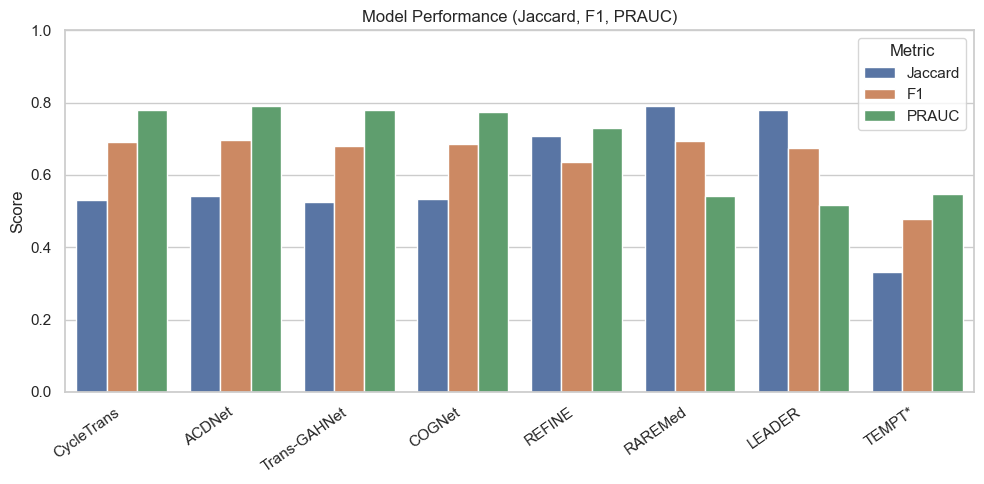

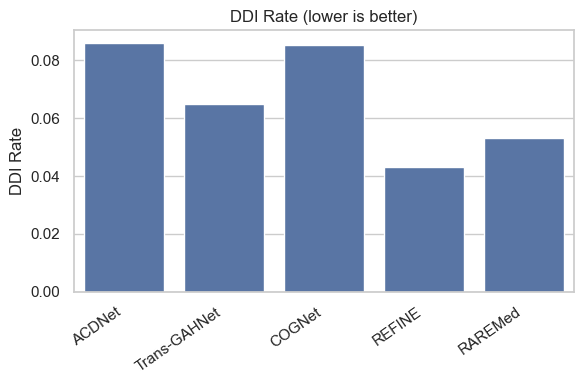

In [1]:
"""
Visualize model performance from the table using Seaborn.

Save as, e.g., plot_models.py and run with:
    python plot_models.py
"""

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


def main():
    # ---- Data from the table ----
    data = {
        "Model": [
            "CycleTrans", "ACDNet", "Trans-GAHNet", "COGNet",
            "REFINE", "RAREMed", "LEADER", "TEMPT*"
        ],
        # Approximated values for those with "~" or "*"
        "Jaccard": [0.53, 0.543, 0.524, 0.5336, 0.708, 0.792, 0.780, 0.332],
        "F1":      [0.69, 0.696, 0.679, 0.6869, 0.635, 0.694, 0.674, 0.479],
        "PRAUC":   [0.78, 0.790, 0.780, 0.7739, 0.729, 0.541, 0.518, 0.547],
        # DDI Rate is missing / qualitative for some models
        "DDI":     [None, 0.086, 0.065, 0.0852, 0.043, 0.053, None, None],
    }

    df = pd.DataFrame(data)

    sns.set(style="whitegrid")

    # ---- Plot 1: grouped bars for Jaccard, F1, PRAUC ----
    long_df = df.melt(
        id_vars="Model",
        value_vars=["Jaccard", "F1", "PRAUC"],
        var_name="Metric",
        value_name="Score",
    )

    plt.figure(figsize=(10, 5))
    ax1 = sns.barplot(
        data=long_df,
        x="Model",
        y="Score",
        hue="Metric"
    )
    ax1.set_ylim(0, 1.0)
    ax1.set_title("Model Performance (Jaccard, F1, PRAUC)")
    ax1.set_xlabel("")
    ax1.set_ylabel("Score")
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()

    # ---- Plot 2: DDI Rate comparison ----
    ddi_df = df.dropna(subset=["DDI"])

    plt.figure(figsize=(6, 4))
    ax2 = sns.barplot(
        data=ddi_df,
        x="Model",
        y="DDI",
    )
    ax2.set_title("DDI Rate (lower is better)")
    ax2.set_xlabel("")
    ax2.set_ylabel("DDI Rate")
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()

    plt.show()


if __name__ == "__main__":
    main()


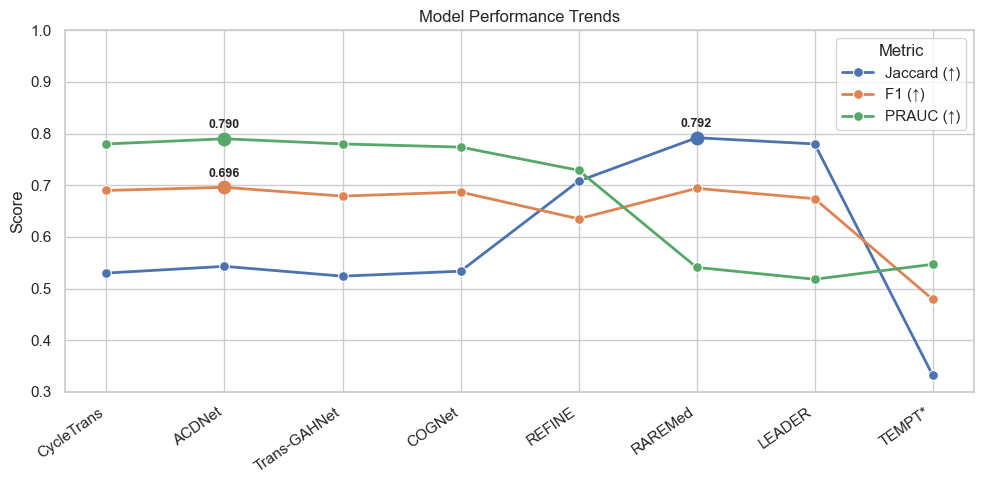

In [5]:
"""
Improved multi-line performance trend plot with:
- Legend labels: Jaccard (↑), F1 (↑), PRAUC (↑)
- Value labels on the highest point of each metric
"""

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


def main():
    # ---- Data from the table ----
    data = {
        "Model": [
            "CycleTrans", "ACDNet", "Trans-GAHNet", "COGNet",
            "REFINE", "RAREMed", "LEADER", "TEMPT*"
        ],
        "Jaccard (↑)": [0.53, 0.543, 0.524, 0.5336, 0.708, 0.792, 0.780, 0.332],
        "F1 (↑)":      [0.69, 0.696, 0.679, 0.6869, 0.635, 0.694, 0.674, 0.479],
        "PRAUC (↑)":   [0.78, 0.790, 0.780, 0.7739, 0.729, 0.541, 0.518, 0.547],
    }

    df = pd.DataFrame(data)

    # Keep model order as given
    df["Model"] = pd.Categorical(df["Model"], categories=data["Model"], ordered=True)

    long_df = df.melt(
        id_vars="Model",
        value_vars=["Jaccard (↑)", "F1 (↑)", "PRAUC (↑)"],
        var_name="Metric",
        value_name="Score"
    )

    sns.set(style="whitegrid")

    plt.figure(figsize=(10, 5))
    ax = sns.lineplot(
        data=long_df,
        x="Model",
        y="Score",
        hue="Metric",
        marker="o",
        linewidth=2,
        markersize=7,
    )

    # Annotate the highest point of each metric
    for metric in long_df["Metric"].unique():
        sub = long_df[long_df["Metric"] == metric]
        best_row = sub.loc[sub["Score"].idxmax()]

        # Highlight the best point
        ax.scatter(best_row["Model"], best_row["Score"], s=80, zorder=5)

        # Add numeric label slightly above the point
        ax.text(
            best_row["Model"],
            best_row["Score"] + 0.015,
            f"{best_row['Score']:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold",
        )

    ax.set_title("Model Performance Trends")
    ax.set_xlabel("")
    ax.set_ylabel("Score")
    ax.set_ylim(0.3, 1.0)
    plt.xticks(rotation=35, ha="right")
    plt.legend(title="Metric")
    plt.tight_layout()
    svg_path = "model_performance_trend.svg"
    plt.savefig(svg_path, format="svg")
    plt.show()


if __name__ == "__main__":
    main()
